# Science Calibration & Verfication PIC (scvPIC) 2.2.0.1

This notebook explores the scvPIC 2.2.0.1 catalogue.

**Prerequsites** 

To run this notebook you need to download the PIC 2.1.0.1 from the [PAX](https://pax.esac.esa.int/plato/#/pages/catalog-explorer). Unzip the following two files:

- `LOPS2PICtarget2.2.0.1-t-fg-c-scv.fits`
- `LOPS2PICcontaminant2.2.0.1-t-fg-c-scv.fits`

and place them in the location: `$PLATO_PROJECT_HOME/inputfiles/data_picsim`.

**Documentation** 

The following technical notes helps you understand the PIC:

- `LOPS2PIC2.2.0.1 Release Notes (for PIC users)`
- `LOPS2PIC2.2.0.1 Data Definition Document`

**Last checked** 

This notebook was last functional with the PlatoSim version:

- `PlatoSim 3.7.0-191-g42fc64d4`

In [5]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
# Default packages
import os
import sys
import glob

# PlatoSim default
import scipy
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt

# PLATOnium default
from pathlib import Path
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy import units as u
from tqdm import tqdm

# PlatoSim libraries
import platosim.plot      as pt
import platosim.utilities as ut
import platosim.starquery as sq
from platosim.simfile import SimFile
from platosim.pic          import PIC2201
from platosim.matplotlibrc import setup_paper
setup_paper(warning=False)

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [121]:
path = ut.getHomeDir('inputfiles/data_picsim')
wdir = ut.getWorkDir('plato_scvPIC')
idir = wdir / 'input'
odir = wdir / 'output'
fdir = wdir / 'figures'
ddir = wdir / 'data'

---
## Load PIC 2.2.0.1 targets
---

In [69]:
filename_targets = path / 'LOPS2PICtarget2.2.0.1-t-fg-c-scv.fits'

In [70]:
pic = PIC2201(filename_targets)

In [71]:
filename_targets = path / 'LOPS2PICtarget2.2.0.1-t-fg-c-scv.fits'
table = Table.read(filename_targets, format='fits')
df = table.to_pandas()
df.head()

,PICid,PICname,StarName,RAdeg,eRAdeg,DEdeg,eDEdeg,pmRA,epmRA,pmDE,...,BOLnCameraObsNCAM_T,BOLnCameraSatNCAM_T,EOLrandomNSRNCAM_R,EOLrandomSysNSRNCAM_R,EOLnCameraObsNCAM_R,EOLnCameraSatNCAM_R,tPICscientificRanking,scvPICscientificRanking,scientificPriority,scheduledTarget
0,3098133000271,b'PIC 3098133000271',b'Gaia DR3 4648564604791874688',84.548965,0.159458,-75.874403,0.180793,-3.102064,0.012864,12.663421,...,0,0,133.600006,133.899994,0,0,0.004622,<NA>,<NA>,<NA>
1,3098130000327,b'PIC 3098130000327',b'Gaia DR3 4648246433616908160',82.636521,0.126920,-75.871390,0.139425,20.555716,0.010246,40.802000,...,0,0,152.399994,152.699997,0,0,0.015314,<NA>,<NA>,<NA>
2,3098125000342,b'PIC 3098125000342',b'Gaia DR3 4648987573177352576',79.661507,0.174732,-75.867457,0.157135,-4.791629,0.013962,9.420978,...,0,0,281.799988,282.000000,0,0,0.000974,<NA>,<NA>,<NA>
3,3098136000261,b'PIC 3098136000261',b'Gaia DR3 4648377790895956096',86.259963,0.163587,-75.861752,0.200761,-1.406063,0.013268,22.950370,...,0,0,152.399994,152.699997,0,0,0.000776,<NA>,<NA>,<NA>
4,3098125000383,b'PIC 3098125000383',b'Gaia DR3 4648987465797348480',79.572931,0.187630,-75.858905,0.174225,7.379638,0.014900,-5.899641,...,0,0,279.700012,279.799988,0,0,0.001540,<NA>,<NA>,<NA>


In [72]:
# Add Galactic coordinates
gal = SkyCoord(df.RAdeg, df.DEdeg, frame='icrs', unit=u.deg).galactic
# Create data frame
dt = pd.DataFrame()
dt['PIC']     = df.PICid
dt['gaiaDR3'] = pic.get_GDR3idnumber()
dt['l']       = gal.l.deg
dt['b']       = gal.b.deg
dt['ra']      = df.RAdeg
dt['dec']     = df.DEdeg
dt['pmra']    = df.pmRA
dt['pmdec']   = df.pmDE
dt['Pmag']    = df.PlatoMagNCAM
dt['PBmag']   = df.PlatoMagFCAMb
dt['PRmag']   = df.PlatoMagFCAMr
dt['M']       = df.Mass
dt['R']       = df.Radius
dt['Teff']    = df.Teff
dt['logg']    = pic.get_logg()
dt['ncams']   = df.BOLnCameraObsNCAM_T
dt['case']    = df.caseFlag
dt['source']  = df.PICmainSourceFlagBOL
dt['tPIC']    = df.tPICsourceFlagNCAM_BOL
dt['fgPIC']   = df.fgPICsourceFlag
dt['cPIC']    = df.cPICsourceFlag
dt['scvPIC']  = df.scvPICsourceFlag
dt.ncams.unique()

<IntegerArray>
[0, 6, 12, 18, 24, <NA>]
Length: 6, dtype: Int16

---
## F-CAM visibility
---

### Full-frame CCD images

In [122]:
# Load F-CAM blue
cam = 2
f1 = SimFile(odir / f'Fcam{cam}_Q1_ccd1.hdf5')
f2 = SimFile(odir / f'Fcam{cam}_Q1_ccd2.hdf5')
f3 = SimFile(odir / f'Fcam{cam}_Q1_ccd3.hdf5')
f4 = SimFile(odir / f'Fcam{cam}_Q1_ccd4.hdf5')

In [123]:
# Fetch CCD images
im1 = f1.getImage(0)
im2 = f2.getImage(0)
im3 = f3.getImage(0)
im4 = f4.getImage(0)

<IPython.core.display.Javascript object>


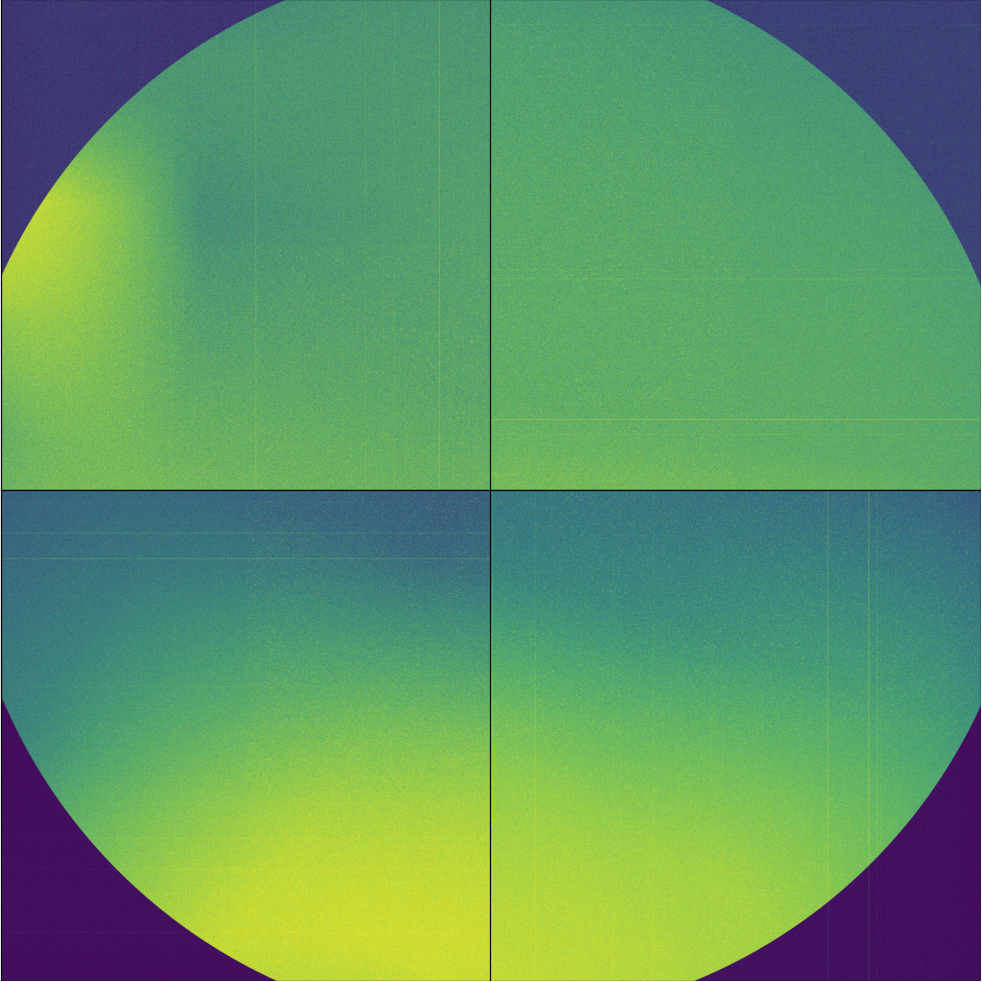

In [124]:
# Plot FPA in a subplot
fig = plt.figure(figsize=(9,9))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

axs = [ax1, ax2, ax3, ax4]
ims = [im1, im4, im2, im3]
ang = [180,  270,  90,  0]

for ax, im, a in zip(axs, ims, ang):
    
    im = ut.imageNorm(im, "log", sigma=0.1)
    vmin = im.min()
    vmax = im.max()
    norm = 'linear'

    ax.imshow(sp.ndimage.rotate(im, a), norm=norm, origin='lower')
    ax.xaxis.set_ticks([])
    ax.yaxis.set_ticks([])
    
plt.tight_layout(pad=0)
# fig.savefig(f'{fdir}/full_frame_image_group4.png', bbox_inches='tight', dpi=200)

In [125]:
# Load F-CAM stars on silicon
df1 = pd.read_feather(odir / f'Fcam{cam}_Q1_ccd1.ftr')
df2 = pd.read_feather(odir / f'Fcam{cam}_Q1_ccd2.ftr')
df3 = pd.read_feather(odir / f'Fcam{cam}_Q1_ccd3.ftr')
df4 = pd.read_feather(odir / f'Fcam{cam}_Q1_ccd4.ftr')
df = pd.concat([df1, df2, df3, df4]).drop_duplicates(subset='PIC').reset_index(drop=True)
df

,starID,PIC,gaiaDR3,l,b,ra,dec,pmra,pmdec,Pmag,...,tPIC,fgPIC,cPIC,scvPIC,flux,xCCD,yCCD,xFP,yFP,rOA
0,8483,3015413001752,4659872493472190592,276.390743,-31.353636,86.127127,-66.518029,-7.079871,1.687529,12.052428,...,4,0,0,0,6995.0,4496.766515,2482.665417,-81.388250,38.102569,19.980181
1,8499,3015411002041,4659899126601989888,276.400937,-31.596457,85.517734,-66.510349,-3.297123,6.010059,12.440636,...,4,0,0,0,4665.0,4490.814885,2417.766299,-81.281120,39.270754,20.063063
2,8540,3015413002231,4659872841400822912,276.353665,-31.295476,86.277585,-66.489966,2.065043,33.296254,10.992801,...,4,0,0,0,16183.0,4489.490936,2499.968624,-81.257289,37.791112,19.928901
3,8578,3015417001989,4659767356984847488,276.303824,-30.749589,87.649198,-66.473785,-2.508348,-0.653538,12.502638,...,4,0,0,0,4157.0,4496.210043,2646.650279,-81.378233,35.150842,19.729919
4,8582,3015415002110,4659864320185330688,276.317168,-31.048855,86.898955,-66.472242,-0.467619,17.331145,12.523161,...,4,0,0,0,4176.0,4488.989155,2567.029170,-81.248257,36.584022,19.824234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61939,216321,2668960000095,5571000469030754048,251.226421,-26.408678,91.379779,-44.169393,-1.065928,1.111601,12.730709,...,0,0,0,8192,3740.0,430.290760,3592.217895,18.220507,8.111806,4.613311
61940,217161,2586117000006,2882550326999675008,246.785320,-25.961826,90.674338,-40.193480,-1.362313,2.593401,12.503849,...,0,0,0,8192,4810.0,375.934601,2608.832059,35.921530,7.134803,8.428204
61941,217242,2575872000017,2882756932106461184,246.091252,-26.370952,89.953689,-39.693303,0.727749,2.727054,12.486994,...,0,0,0,8192,4874.0,487.421915,2459.762527,38.604622,9.141788,9.118539
61942,217314,2610664000053,4804662163212422528,247.039026,-29.927087,85.638592,-41.299816,0.287557,3.979917,12.403993,...,0,0,0,8192,5183.0,1342.699912,2724.046463,33.846287,24.536414,9.599705


### Check request from scvPIC team

In [130]:
# Cross-match with tPIC
dt0 = dt[dt['PIC'].isin(df['PIC'])].sort_values(by=['Pmag']).reset_index(drop=True)

# Select scvPIC stars only
dt1 = dt0.loc[dt0['source'] & 32 == 32]

# Select stars below PRmag < 8
dt2 = dt1[(dt1.PRmag < 8)].reset_index(drop=True)

In [131]:
# Count number of star observed with F-CAMs in tPIC, scvPIC, and maglim scvPIC
dt0.shape[0], dt1.shape[0], dt2.shape[0]

(61944, 10682, 245)

In [128]:
# Count number of stars below mag-lim with N-CAM, F-CAMb, and F-CAMr
dt1[dt1.Pmag < 8].shape[0], dt1[dt1.PBmag < 8].shape[0], dt1[dt1.PRmag < 8].shape[0]

(182, 140, 245)

In [132]:
# Number of scvPIC stars on F-CAM silicon
dx = dt.loc[dt['source'] & 32 == 32]
dx[dx.PRmag < 8].shape[0]

846

In [133]:
# Save catalogue for scvPIC team
dt2.to_csv(ddir / 'data_scvPIC2201_LOPS2_FCAMr8.csv', index=False)

<IPython.core.display.Javascript object>


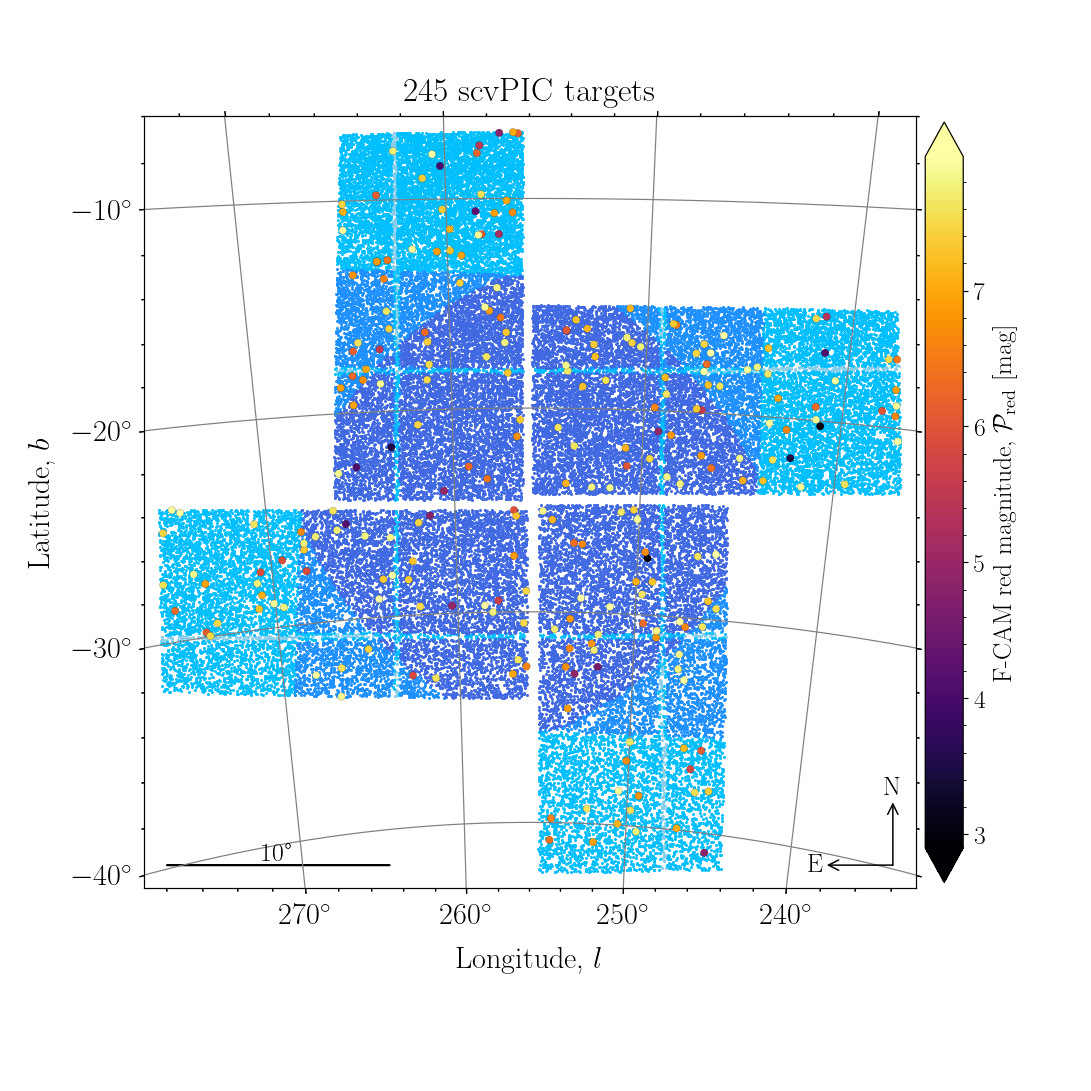

In [134]:
dx = dt2
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=19, ncamStars=df,
    # Plot stars
    raStars=dx.ra, decStars=dx.dec, c=dx.PRmag, s=100, 
    cmap='inferno', clabel=r'F-CAM red magnitude, $\mathcal{P}_{\rm red}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} scvPIC targets'
)
fig.savefig(fdir / 'flower_scvPIC2101_LOPS2_FCAMr8.png', bbox_inches='tight', dpi=200)

---
## scvPIC help for Konstanze 2025
---

Load new scvPIC:

In [ ]:
ds = pd.read_csv(hdir / 'LOPS2scvPICtarget2.2.0.1_input_v1.csv', names=['gaiaDR3', 'scv', 'mag', 'p'])

### Match source with PIC 2.1.0.1 contaminant table

In [ ]:
path = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/data_picsim/LOPS2PIC2.1.0.1-t-fg-c-scv/Data' 
filename = path / 'LOPS2PICcontaminant2.1.0.1-t-fg-c-scv.fits'
hdul = fits.open(filename, memmap=True)

In [ ]:
dc = pd.DataFrame()
campos = {
    'gaiaDR3' : 'StarName',
    'ra'      : 'RAdeg', 
    'dec'     : 'DEdeg',
    'pmra'    : 'pmRA',
    'pmdec'   : 'pmDE',
    'Pmag'    : 'PlatoMagNCAM',
    'PBmag'   : 'PlatoMagFCAMb',
    'PRmag'   : 'PlatoMagFCAMr'
}
for campo_dc, campo_pic in campos.items():
    # Print each column to follow progress
    print(campo_pic)
    col = hdul[1].data[campo_pic]
    # Fetch magnitude column and get bool indices for P < 19
    if campo_dc == 'Pmag':
        dx = pd.DataFrame({'Pmag': col})
        dex = dx.Pmag < 17
    # Fetch each column
    dc[campo_dc] = col.byteswap().view(col.dtype.newbyteorder())
print(f'Number of sources found: {dc.shape[0]/1e6}')
dc.head()

Match catalogues with Gaia DR3 entries:

In [ ]:
dc_scv = dc[dc['gaiaDR3'].isin(dt['gaiaDR3'])]
dc_scv.shape[0]

In [ ]:
dt_scv = dt[dt['gaiaDR3'].isin(dc_scv['gaiaDR3'])]
dt_scv.shape[0]

This is the number of stars without Gaia DR3 entries:

In [ ]:
ds.shape[0] - dt_scv.shape[0]

### Handle duplicates sources of the scvPIC

Fetch coordinates and magnitude:

In [ ]:
N = dt_scv.shape[0]
ra = np.zeros(N)
dec = np.zeros(N)
Pmag = np.zeros(N)
for i in tqdm(range(N), bar_format=ut.tqdmBar()):
    dx = dc_scv[dc_scv.gaiaDR3 == dt_scv.gaiaDR3.iloc[i]]
    ra[i] = dx.ra
    dec[i] = dx.dec
    Pmag[i] = dx.Pmag

In [ ]:
df = dt_scv
df['ra']   = ra
df['dec']  = dec
df['Pmag'] = Pmag
gal = SkyCoord(df.ra, df.dec, frame='icrs', unit=u.deg).galactic
df['l'] = gal.l.deg
df['b'] = gal.b.deg

### Handle bright SCV2b stars with different star names

Out of which some are bright stars with different names:

In [ ]:
dx = dt[~dt.gaiaDR3.str.startswith(tuple(['Gaia DR3']))]
dx

In [ ]:
dx.gaiaDR3.iloc[0]

In [ ]:
dx0 = pd.DataFrame()
N = dx.shape[0]
dex = []
for i in tqdm(range(N), bar_format=ut.tqdmBar()):
    try:
        dx_i = dx.iloc[i]
        dx1 = sq.simbadQuery(dx_i.gaiaDR3, radius=100)
        dx1 = dx1.loc[0].to_frame().T
        dx1['']
        dx0 = pd.concat([dx0, dx1])
    except:
        dex.append(i)

In [ ]:
dx0

## scvPIC 2.2.0.2

In [ ]:
dx = pd.read_csv('LOPS2scvPICtarget2.2.0.2.csv')
dx.columns

In [ ]:
# Add Galactic coordinates
gal = SkyCoord(dx.RAdeg, dx.DEdeg, frame='icrs', unit=u.deg).galactic
# Create data frame
df = pd.DataFrame()
df['PIC']     = dx.scvPICid
df['gaiaDR3'] = dx.StarName
df['l']       = gal.l.deg
df['b']       = gal.b.deg
df['ra']      = dx.RAdeg
df['dec']     = dx.DEdeg
df['pmra']    = dx.pmRA
df['pmdec']   = dx.pmDE
df['Pmag']    = dx.PlatoMagNCAM
# dt['PBmag']   = df.PlatoMagFCAMb
# dt['PRmag']   = df.PlatoMagFCAMr
# dt['M']       = df.Mass
# dt['R']       = df.Radius
# dt['Teff']    = df.Teff
# dt['logg']    = pic.get_logg()
df['ncams']   = dx.BOLnCameraObsNCAM_T
# dt['case']    = df.caseFlag
# df['source']  = dx.PICmainSourceFlagBOL
# dt['tPIC']    = df.tPICsourceFlagNCAM_BOL
# dt['fgPIC']   = df.fgPICsourceFlag
# dt['cPIC']    = df.cPICsourceFlag
df['scvPIC']  = dx.scvPICsourceFlag

## Plot each scvPIC sample

In [ ]:
dt = pd.read_feather(path / '../../PIC210_LOPS2_targets.ftr')

In [ ]:
dx = df[(df.ncams != 0)]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot P1 sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=10, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} scvPIC targets'
)
fig.savefig('skymap_LOPS2_scvPIC2202.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '1a']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 1 == 1]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot P1 sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=50, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV1a targets (eclipsing binaries)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV1a.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '1b']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 2 == 2]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot P1 sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=50, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV1b targets (astrometric binaries)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV1b.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '1c']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 4 == 4]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot P1 sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=70, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV1c targets (wide binaries)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV1c.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '1d']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 8 == 8]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot P1 sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=200, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV1d targets (HW Vir-type binaries)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV1d.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '1e']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 16 == 16]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot P1 sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV1e targets (wide WD binaries)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV1e.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '2a']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 32 == 32]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot P1 sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV2a targets (legacy and benchmark)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV2a.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '2b']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 64 == 64]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=32, ncamStars=dt,
    # Plot P1 sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=50, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV2b targets (legacy and benchmark)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV2b.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '3a']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 128 == 128]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV3a targets (photometric stable)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV3a.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '3b']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 256 == 256]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=70, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV3b targets (photometric stable)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV3b.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '4a']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 512 == 512]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=70, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV4a targets (solar-like pulsators)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV4a.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '4b']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 1024 == 1024]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=10, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV4b targets (solar-like pulsators)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV4b.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '5']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 2048 == 2048]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=30, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV5 targets (gamma Dor pulsators)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV5.png', bbox_inches='tight', dpi=200)

In [ ]:
# dx = df[df.scv == '6']
dx = df[(df.ncams != 0)]
dx = dx.loc[dx['scvPIC'] & 4096 == 4096]
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot sample stars
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=200, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(10,10), title=f'{dx.shape[0]} SCV6 targets (transiting exoplanets)'
)
fig.savefig('skymap_LOPS2_scvPIC2202_SCV6.png', bbox_inches='tight', dpi=200)